# Определение возраста пользователя для корректного показа рекламы

**Цель проекта:**

Разработать модель машинного обучения, способную определять возрастную категорию анонимного пользователя на основе данных о его поведении в интернете для повышения эффективности возрастного таргетинга рекламы.

**Задачи проекта:**

- Провести анализ и подготовку данных о посещении сайтов пользователями, включая обработку пропусков и выделение информативных признаков.
- Построить и обучить модель машинного обучения для классификации пользователей по возрастным категориям на основе их цифрового поведения.
- Оценить качество работы модели и определить её пригодность для использования в системе рекламного таргетинга компании.

## 1. Подготовка среды и загрузка данных

In [3]:
# Установка зависимостей
!pip install -q scikit-learn numpy pandas seaborn phik joblib

In [4]:
# Импорт основных библиотек
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import phik
import joblib

In [5]:
# Random state
RANDOM_STATE=1703

# Целевая переменная
TARGET_COL = 'age_category'

In [6]:
# Загрузка датасета с кешированием на диске
data_files = {
    'users': 'ds_s13_users.csv',
    'visits': 'ds_s13_visits.csv',
    'ads_activity': 'ads_activity.csv',
    'surf_depth': 'surf_depth.csv',
    'primary_device': 'primary_device.csv',
    'cloud_usage': 'cloud_usage.csv'
}

dfs = {}

for file, file_path in data_files.items():
    try:
        dfs[file] = pd.read_csv(f'./10. {file_path}')
        print(f'Dataset {file} found locally.')
    except:
        print(f'Dataset {file} not found locally.')
        dfs[file] = pd.read_csv(f'https://code.s3.yandex.net/datasets/{file}')
        dfs[file].to_csv(f'./10. {file}')

Dataset users found locally.
Dataset visits found locally.
Dataset ads_activity found locally.
Dataset surf_depth found locally.
Dataset primary_device found locally.
Dataset cloud_usage found locally.


Выведем только размеры полученных датасетов, чтобы убедиться, что загрузка прошла успешно:

In [7]:
for file, df in dfs.items():
    print(f'{file}: {df.shape}')

users: (5913, 3)
visits: (1065745, 6)
ads_activity: (5826, 3)
surf_depth: (5715, 3)
primary_device: (5669, 3)
cloud_usage: (5680, 3)


Все 6 датасетов загружены корректно. Их размеры выглядят в соответствии описанию

## 2. Исследовательский анализ данных (EDA)

Так как вместо одного общего датасета изначально есть 6 разных изучим каждый отдельно по очереди по следующим шагам:
1. Базовая информация о датасета
2. Общий анализ признаков
3. Анализ пропусков
4. Выявление дубликатов
5. Анализ категориальных признаков
6. Анализ выбросов и распределений
7. Вывод

### 2.1. Таблица `users`

#### 2.1.1 Базовая информация о датасете
 
Таблица содержит информацию о возрастной категории пользователя.
 
**Столбцы:**
- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, целевая переменная для предсказания моделью.

**Возможные значения `age_category`:**
- 0: младше 18
- 1: 18–25 лет
- 2: 26–40 лет
- 3: 41–55 лет
- 4: 56+ лет

In [8]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['users']

In [9]:
# Размер датасета
df.shape

(5913, 3)

In [10]:
# Первые строки датасета
df.head()

,Unnamed: 0,user_id,age_category
0,0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,2,678b-614cd47d854b9d591db2-000b2e50,0
3,3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


#### 2.1.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [11]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [12]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


In [13]:
# Информация о целевой переменной
df[TARGET_COL].value_counts()

age_category
4    1794
2    1467
3    1269
0     863
1     520
Name: count, dtype: int64

Id пользователя представлен строкой, что нормально для формата id похожего на  uuid. Далее будем заострять внимание на этом столбце, только если будут замечены несоответствия типа или формата

Целевая переменная представлена типом `int64`, который явно велик для всех 5 возможных значений переменной. Переменная уже закодирована в удобный для дальнейшей работы формат, так что только сделаем downcast типа для небольшой экономии времени и места

In [14]:
# Downcast типа целевой переменной
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], downcast='integer')  

df.dtypes


user_id          str
age_category    int8
dtype: object

In [15]:
# Проверка id на то что все символы в нижнем регистре
(df['user_id'] != df['user_id'].str.lower()).sum()

np.int64(0)

Все id содержат буквы только в нижнем регистре. Это позволит упростить дальнейшую проверку на дубликаты и сбор единого датасета

#### 2.1.3 Анализ пропусков

In [16]:
# Пропуски по столбцам
df.isna().sum()

user_id         0
age_category    0
dtype: int64

Пропусов не выявлено

#### 2.1.4 Выявление дубликатов

Проверим, встречается ли несколько раз пользователь с одинаковым id

In [17]:
# Количество дублей user_id
(df['user_id'].duplicated()).sum()

np.int64(87)

In [18]:
# Количество дублей user_id + age_category
(df.duplicated()).sum()

np.int64(87)

В данных выявлено 87 полных дубликатов. Количество незначатильно относительно общего объема данных. Сразу удалим их

In [19]:
# Удаление дубликатов
print('Количество строк до удаления: ', len(df))

df = df.drop_duplicates()

print('Количество строк после удаления: ', len(df))

Количество строк до удаления:  5913
Количество строк после удаления:  5826


#### 2.1.5 Анализ категориальных признаков (Анализ целевой переменной)

In [20]:
# Функция обертка для построения столбчатой диаграммы
def countplot(data, x=None, y=None, *, order=None, hue=None, title=None,
              xlabel=None, ylabel=None,
              show_numbers=True):

    ax = sns.countplot(data=data, x=x, y=y, order=order, hue=hue)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if show_numbers:

        total = len(data)

        # Вертикальный график
        if x is not None:
            for p in ax.patches:
                value = int(p.get_height())

                _x = p.get_x() + p.get_width() / 2
                _y = p.get_height()

                ax.annotate(
                    f'{value} ({value/total:.2%})',
                    (_x, _y),
                    ha='center',
                    va='bottom'
                )

        elif y is not None:
            max_count = 0
            
            for p in ax.patches:
                value = int(p.get_width())
                max_count = max(max_count, value)

                _x = p.get_width()
                _y = p.get_y() + p.get_height() / 2

                ax.annotate(
                    f'{value} ({value/total:.2%})',
                    (_x, _y),
                    ha='left',
                    va='center',
                    xytext=(5, 0),
                    textcoords='offset points'
                )

            ax.set_xlim(right=max_count * 1.35)

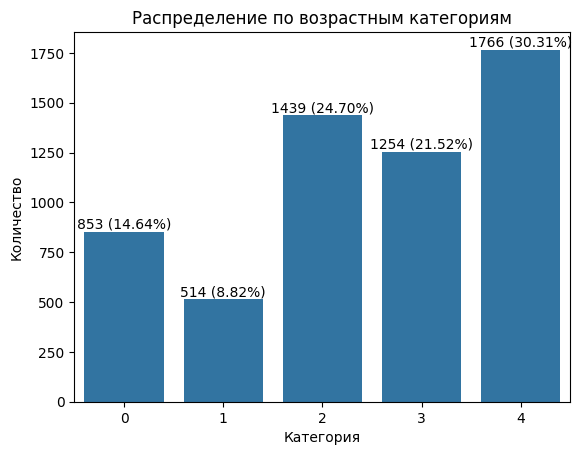

In [21]:
# Распределение пользователей по возрастным группам
countplot(
    data=df,
    x=TARGET_COL,
    title='Распределение по возрастным категориям',
    xlabel='Категория',
    ylabel='Количество'
)

Заметен сильный дисбаланс классов. Доля классов в выборке варьируется от 0.3 для группы 56+ лет, до 0.09 для группы 18-25 лет. Это потребуется учесть при разбиение данных на выборки и обучении моделей

#### 2.1.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.1.7 Вывод

Датасет `users` содержит информацию о пользователях, включая их уникальный идентификатор (user_id) и возрастную категорию (age_category). 

После очистки данных и удаления дубликатов получено 5826 уникальных записей. 

Распределение по возрастным категориям неравномерное - наблюдается дисбаланс классов, где наибольшее количество относится к старшей возрастной группе (56+ лет), а наименьшее - к младшей (18-25 лет). 

Признаков пропусков или выбросов не обнаружено. Столбцы корректно типизированы.

In [22]:
# Сохранение обновленной таблицы users
dfs['users'] = df

### 2.2. Таблица `visits`

#### 2.2.1 Базовая информация о датасете

Датасет `visits` содержит логи посещений сайтов и по структуре и содержанию напоминает данные “Яндекс Метрики”. Данные предназначены для анализа пользовательской активности. В целях обезличивания все URL-адреса заменены на анонимизированные категории сайтов, а вместо конкретного времени зафиксирована только категория времени суток.

**Столбцы:**
- `user_id` — уникальный идентификатор пользователя;
- `date` — дата посещения сайта;
- `daytime` — категория времени суток, когда было зафиксировано посещение (утро, день, вечер, ночь);
- `session_id` — уникальный идентификатор сессии пользователя (сессия — это последовательность действий пользователя, объединённых правилами тайм-аута или смены условий);
- `website_category` — категория сайта вместо исходного URL. Категорий несколько десятков, что позволяет сегментировать аудиторию и сократить размерность признакового пространства без потери качества модели.

In [23]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['visits']

In [24]:
# Размер датасета
df.shape

(1065745, 6)

In [25]:
# Первые строки датасета
df.head()

,Unnamed: 0,date,daytime,session_id,user_id,website_category
0,0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


В таблице хранится немного больше миллиона строк. Перед обучением модели эти данные потребуется сагрегировать по user_id. Правила агрегации определим далее

#### 2.2.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [26]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [27]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


Все признаки представлены строковыми типами. Преобразований типов не требуется

Признак `session_id` можно удалить из данных. Уникальных идентификатор сесии не будет полезен для модели и не потребуется в дальнейшей обработке данных

In [28]:
# Удаление служебного столбца
df = df.drop(columns=['session_id'])

Приведем все признаки к нижнему регистру, чтобы избежать потенциальных неявных дубликатов

In [29]:
# Приведение всех строковых столбцов к нижнему регистру
for col in df.columns:
    df[col] = df[col].str.lower()

df.head()

,date,daytime,user_id,website_category
0,2025-11-01,вечер,0010-5cf8f6b38a7b6c70a021-009dbcda,category 17
1,2025-11-01,вечер,0010-5cf8f6b38a7b6c70a021-009dbcda,category 19
2,2025-11-01,вечер,0010-5cf8f6b38a7b6c70a021-009dbcda,category 18
3,2025-11-01,вечер,0010-5cf8f6b38a7b6c70a021-009dbcda,category 20
4,2025-11-01,вечер,0010-5cf8f6b38a7b6c70a021-009dbcda,category 05


Подробнее рассмотрим значения признаков далее

#### 2.2.3 Анализ пропусков

In [30]:
# Пропуски по столбцам
df.isna().sum()

date                0
daytime             0
user_id             0
website_category    0
dtype: int64

Пропусов не выявлено

В продакшен данных могут возникнуть пропуски. Для них в пайплайне предусмотрим заполнение самым часто встречаемым значением

#### 2.2.4 Выявление дубликатов

Так как поведение пользователей может быть очень разнообразным, рассмотрим только полные явные дубликаты:

In [31]:
# Количество дублей
(df.duplicated()).sum()

np.int64(155860)

В данных выявлено 155860 полных дубликатов. Количество значительное относительно общего объема данных. Но нам ничего не осталется, кроме как удалить их, чтобы предотвратить негативное влияние на обучение моделей

In [32]:
# Удаление дубликатов
print('Количество строк до удаления: ', len(df))

df = df.drop_duplicates()

print('Количество строк после удаления: ', len(df))

Количество строк до удаления:  1065745
Количество строк после удаления:  909885


#### 2.2.5 Анализ категориальных признаков (Анализ целевой переменной)

Данный датасет в основном представлен категориальными признаками. Из них потенциально в изначальном виде полезные:
- `daytime`
- `website_category`

In [33]:
# Промежуточк дат в данных
min(df['date']), max(df['date'])

('2025-11-01', '2025-11-14')

`date` в изначальном виде мы не будем рассматривать как самостоятельный признак. Но извлечем из него другие потенциально полезные признаки. 

Так как промежуток дат в таблице составляет всего две недели извлекать месяц или день месяца не имеет смысла, но можно получить день недели (`day_of_week`)

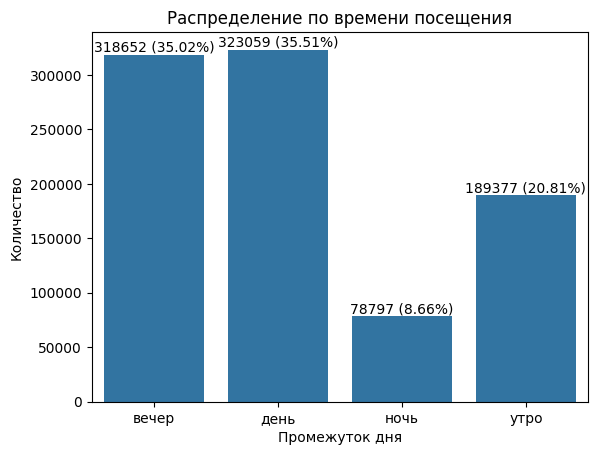

In [34]:
# График распределения daytime
countplot(df, 'daytime', title='Распределение по времени посещения', xlabel='Промежуток дня', ylabel='Количество')

Самое популярное время посещения сайтов день и вечер. Утром и ночью количество посещений заметно падает

Уникальных значений признака четыре. Для его кодирования будет лучше всего воспользоваться OHE

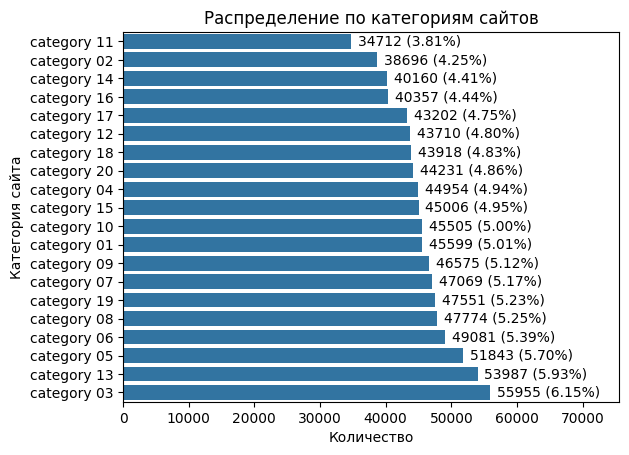

In [35]:
# График распределения website_category
countplot(
    df, 
    y='website_category', 
    order=df['website_category'].value_counts().sort_values().index,
    title='Распределение по категориям сайтов', 
    ylabel='Категория сайта', 
    xlabel='Количество'
)

Наибольшую долю занимает category 03 — около 6.15% (55 955 сайтов), а наименьшую — category 11 с 3.81% (34 712 сайтов).

В целом распределение категорий достаточно равномерное: доли всех категорий находятся примерно в диапазоне от 4% до 6%, без сильного перекоса в одну категорию.

Уникальных значений признака 20. Для его кодирования будет лучше всего воспользоваться OHE

In [36]:
# Получение дней недели из даты. 
days_of_week = pd.to_datetime(df['date']).dt.day_name()

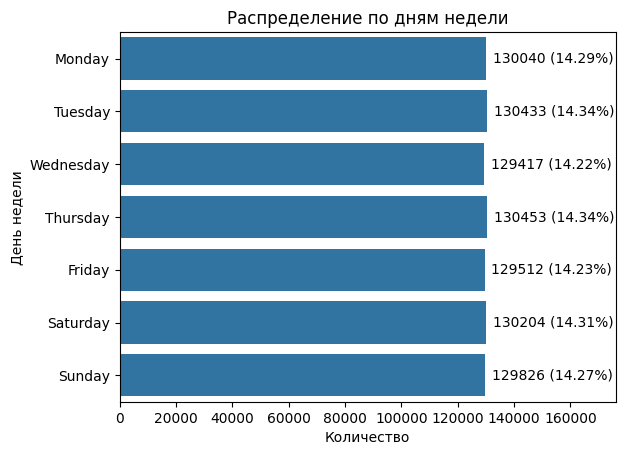

In [37]:
# График распределения дней недели
countplot(
    pd.DataFrame({'dow': days_of_week}), 
    y='dow', 
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    title='Распределение по дням недели', 
    ylabel='День недели', 
    xlabel='Количество'
)

В таком виде распределение по дням недели почти ровное.

Посмотрим на данные в другом разрере. Вычислим самый активный день для каждого пользователя и агрегируем по дням недели

In [38]:
# Вычисление распределения самых активных дней пользователей
df_ = df.copy()
df_['dow'] = pd.to_datetime(df['date']).dt.day_name()
most_popular_days = pd.DataFrame(df_.groupby('user_id')['dow'].agg(lambda x: x.mode()[0]).reset_index())

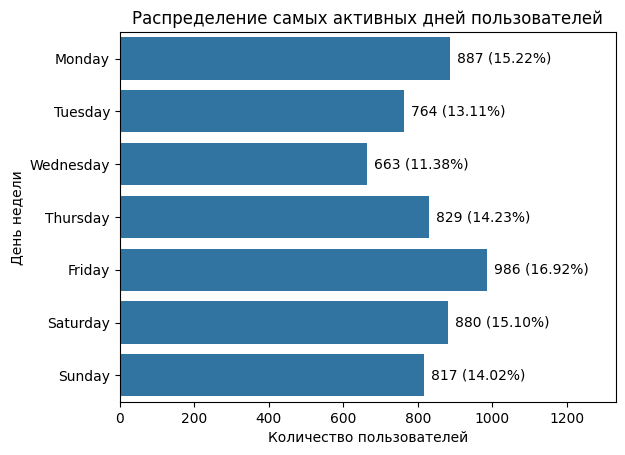

In [39]:
# График распределения самых активных дней пользователей
countplot(
    most_popular_days, 
    y='dow', 
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    title='Распределение самых активных дней пользователей', 
    ylabel='День недели', 
    xlabel='Количество пользователей'
)

Несмотря на то, что каждый день происходит примерно одинаковое количество событий, генерирует это одинаковое количество событий разное количество пользователей. В Понедельник и пятницу больше всего пользователей проявляют свои наибольшую активность, вторник и среда менее популярные дни для повышенной активности пользователей

Для того чтобы сделать окончательный вывод насчет полезности дня недели для модели нужно сопоставить полученные данные с таргетом:

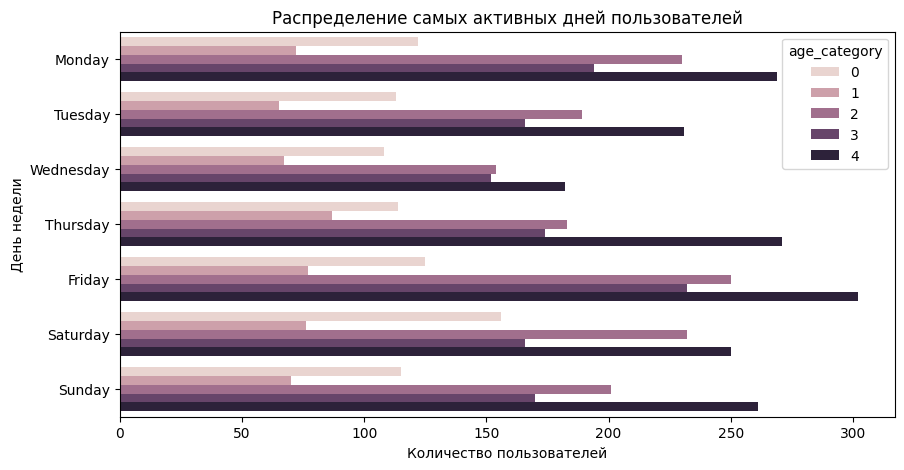

In [40]:
# График распределения самых активных дней пользователей с учетом возрастной группы (таргета)
df_dow_target = pd.merge(most_popular_days, dfs['users'], on='user_id', how='inner')

plt.figure(figsize=(10, 5)) 

countplot(
    df_dow_target, 
    y='dow', 
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    hue='age_category',
    title='Распределение самых активных дней пользователей', 
    ylabel='День недели', 
    xlabel='Количество пользователей',
    show_numbers=False
)

На данном графике прослеживается разный ритм активности пользователей в зависимости от возрастной группы. Но данный график искажает разный размер возрастных групп в выборке. Построим еще один график, но уже с нормализованными значениями 

Text(0, 0.5, 'День недели')

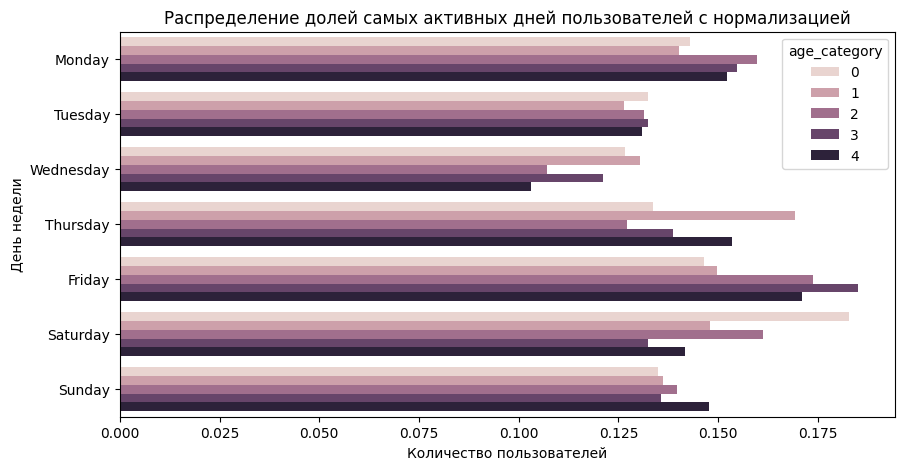

In [41]:
# График распределения самых активных дней пользователей с учетом возрастной группы (таргета) с нормализацией

# Отдельный подсчет пропорций. Встроенные методы нормализации не подошли для жежаемого результата
# Сумма по каждой возрастной категории = 1
plot_df = (
    df_dow_target
    .groupby(['dow', 'age_category'])
    .size()
    .reset_index(name='count')
)

plot_df['proportion'] = (
    plot_df['count'] /
    plot_df.groupby('age_category')['count'].transform('sum')
)

plt.figure(figsize=(10, 5)) 

sns.barplot(
    data=plot_df,
    y='dow',
    x='proportion',
    hue='age_category',
    order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
)

plt.title('Распределение долей самых активных дней пользователей с нормализацией')
plt.xlabel('Количество пользователей')
plt.ylabel('День недели')

In [42]:
# День недели с максимальной нормализованной долей активности для каждой возрастной категории
plot_df.loc[
    plot_df.groupby('age_category')['proportion'].idxmax(),
    ['age_category', 'dow', 'proportion']
]

,age_category,dow,proportion
10,0,Saturday,0.182884
21,1,Thursday,0.169261
2,2,Friday,0.173732
3,3,Friday,0.185008
4,4,Friday,0.171008


День недели явно оказывает влияние на поведение пользователей и влияние немного отличается на пользователей разных возрастных групп. Но влияние не настолько сильное чтобы стать сильно значимым в процессе построения модели

Допустим признак дня недели до обучения моделей и посмотрим, как он себя покажет

#### 2.2.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.2.7 Вывод

Датасет `visits` содержит информацию о посещении сайтов пользователями. Данные совпадают с описанием

После очистки данных и удаления дубликатов получено 909885 уникальных записей. 

Категориальные признаки `daytime` и `website_category` могут быть использованы в обучении, для их кодирования применим One Hot Encoding

Из признака `date` будет получен день недели. День недели влияет на активность пользователей разных возрастов, но не критично, хотя добавление этого признака может немного улучшить классификацию

In [43]:
# Сохранение обновленной таблицы visits
dfs['visits'] = df

### 2.3. Таблица `ads_activity`

#### 2.3.1 Базовая информация о датасете

Датасет `visits` содержит информацию об активность взаимодействия пользователя с рекламными объявлениями — важный показатель, связанный с возрастом.

**Столбцы:**
- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

In [44]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['ads_activity']

In [45]:
# Размер датасета
df.shape

(5826, 3)

In [46]:
# Первые строки датасета
df.head()

,Unnamed: 0,user_id,ads_activity
0,0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,1,35cd-a972339dec534f49332c-a8b6d383,редко
2,2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,4,febd-077f277466253ee04ef6-42656680,умеренно


#### 2.3.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [47]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [48]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB


Все признаки представлены строковыми типами. Преобразований типов не требуется

Приведем все признаки к нижнему регистру, чтобы избежать потенциальных неявных дубликатов

In [49]:
# Приведение всех строковых столбцов к нижнему регистру
for col in df.columns:
    df[col] = df[col].str.lower()

df.head()

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


Подробнее рассмотрим значения признаков далее

#### 2.3.3 Анализ пропусков

In [50]:
# Пропуски по столбцам
df.isna().sum()

user_id         0
ads_activity    0
dtype: int64

Пропусов не выявлено

В продакшен данных могут возникнуть пропуски. Для них в пайплайне предусмотрим заполнение самым часто встречаемым значением

#### 2.3.4 Выявление дубликатов

Проверим, встречается ли несколько раз пользователь с одинаковым id

In [51]:
# Количество дублей user_id
(df['user_id'].duplicated()).sum()

np.int64(233)

In [52]:
# Количество дублей user_id + ads_activity
(df.duplicated()).sum()

np.int64(233)

В данных выявлено 233 полных дубликата. Количество незначатильно относительно общего объема данных. Сразу удалим их

In [53]:
# Удаление дубликатов
print('Количество строк до удаления: ', len(df))

df = df.drop_duplicates()

print('Количество строк после удаления: ', len(df))

Количество строк до удаления:  5826
Количество строк после удаления:  5593


#### 2.3.5 Анализ категориальных признаков

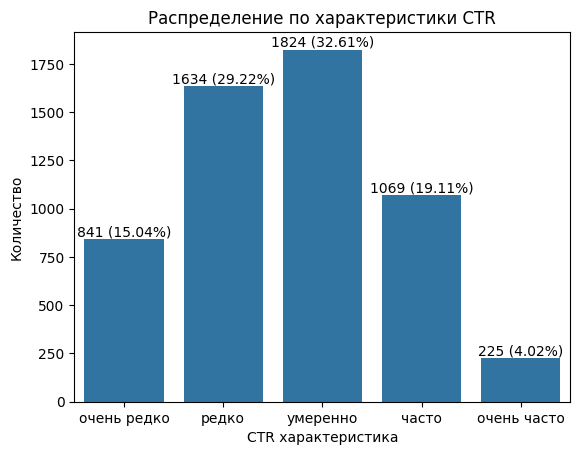

In [54]:
countplot(
    data=df,
    x='ads_activity',
    order=["очень редко", "редко", "умеренно", "часто", "очень часто"],
    title='Распределение по характеристики CTR',
    xlabel='CTR характеристика',
    ylabel='Количество'
)

Заметен сильный дисбаланс классов. Доля классов в выборке варьируется от 0.32 для группы c умеренным CTR, до 0.04 для группы c очень частым CTR.

Посмотрим на разделение по характеристикам CTR в разрезе возрастной категории

In [55]:
# Объединение данных о CTR с таргетом
df_with_target = pd.merge(dfs['users'], df, on='user_id', how='inner')
df_with_target.head(1)

,user_id,age_category,ads_activity
0,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2,умеренно


In [56]:
# Подготовка данных для построения графиков с нормализацией каждой возрастной группы
plot_df = (
    df_with_target
    .groupby(['ads_activity', 'age_category'])
    .size()
    .reset_index(name='count')
)

plot_df['proportion'] = (
    plot_df['count'] /
    plot_df.groupby('age_category')['count'].transform('sum')
)

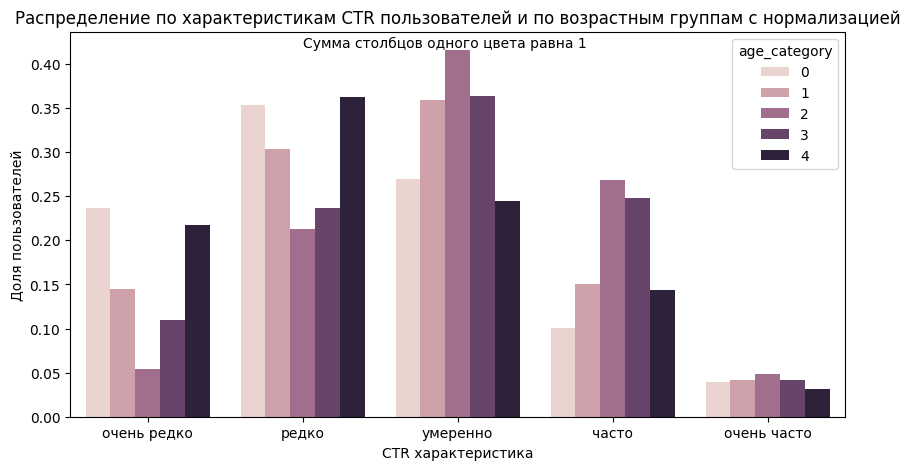

In [57]:
plt.figure(figsize=(10, 5)) 

sns.barplot(
    plot_df, 
    x='ads_activity', 
    y='proportion',
    hue='age_category',
    order=["очень редко", "редко", "умеренно", "часто", "очень часто"],
)

plt.title('Распределение по характеристикам CTR пользователей и по возрастным группам с нормализацией')
plt.suptitle('Сумма столбцов одного цвета равна 1', y=0.87, fontsize=10)
plt.ylabel('Доля пользователей')
plt.xlabel('CTR характеристика')

plt.show()

Распределение CTR по возрастным группам меняется нелинейно: у младших пользователей чаще встречаются низкие значения CTR, у средних возрастных групп преобладают умеренные и частые взаимодействия, а у старшей группы снова увеличивается доля низкого CTR

Этот признак потенциально полезен для построения модели

#### 2.3.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.3.7 Вывод

Датасет `ads_activity` содержит информацию об активности взаимодействия пользователей с рекламными объявлениями и может быть полезен для предсказания возрастной категории.

После очистки данных и удаления дубликатов получено 5593 уникальных записей.

Пропусков не обнаружено, типы признаков корректны.

Распределение по категориям `ads_activity` неравномерное: преобладает класс `умеренно`, а наименее представлен класс `очень часто`, что может быть полезно для модели во время разделения пользователей по возрастным категориям

In [58]:
# Сохранение обновленной таблицы ads_activity
dfs['ads_activity'] = df

### 2.4. Таблица `surf_depth`

#### 2.4.1 Базовая информация о датасете

Датасет `surf_depth` содержит информацию о глубине перехода пользователя по сайтам во время одной сессии

**Столбцы:**
- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

In [59]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['surf_depth']

In [60]:
# Размер датасета
df.shape

(5715, 3)

In [61]:
# Первые строки датасета
df.head()

,Unnamed: 0,user_id,surf_depth
0,0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


#### 2.4.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [62]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [63]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     5715 non-null   str  
 1   surf_depth  5715 non-null   str  
dtypes: str(2)
memory usage: 89.4 KB


Все признаки представлены строковыми типами. Преобразований типов не требуется

Приведем все признаки к нижнему регистру, чтобы избежать потенциальных неявных дубликатов

In [64]:
# Приведение всех строковых столбцов к нижнему регистру
for col in df.columns:
    df[col] = df[col].str.lower()

df.head()

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


Подробнее рассмотрим значения признаков далее

#### 2.4.3 Анализ пропусков

In [65]:
# Пропуски по столбцам
df.isna().sum()

user_id       0
surf_depth    0
dtype: int64

Пропусов не выявлено

В продакшен данных могут возникнуть пропуски. Для них в пайплайне предусмотрим заполнение самым часто встречаемым значением

#### 2.4.4 Выявление дубликатов

Проверим, встречается ли несколько раз пользователь с одинаковым id

In [66]:
# Количество дублей user_id
(df['user_id'].duplicated()).sum()

np.int64(0)

Дубликатов не выявлено

#### 2.4.5 Анализ категориальных признаков

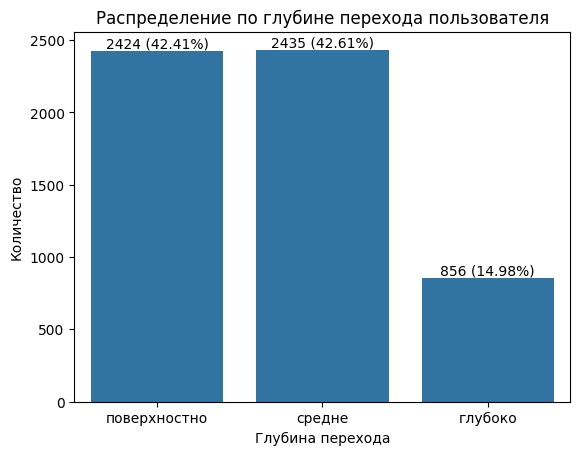

In [67]:
countplot(
    data=df,
    x='surf_depth',
    order=["поверхностно", "средне", "глубоко"],
    title='Распределение по глубине перехода пользователя',
    xlabel='Глубина перехода',
    ylabel='Количество'
)

Пользователи заметно чаще посещают сайты поверхностно или средне глубоко, и гораздо реже глубоко. 

Посмотрим на разделение по глубине перехода в разрезе возрастной категории

In [68]:
# Объединение данных о глубине перехода с таргетом
df_with_target = pd.merge(dfs['users'], df, on='user_id', how='inner')
df_with_target.head(1)

,user_id,age_category,surf_depth
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,глубоко


In [69]:
# Подготовка данных для построения графиков с нормализацией каждой возрастной группы
plot_df = (
    df_with_target
    .groupby(['surf_depth', 'age_category'])
    .size()
    .reset_index(name='count')
)

plot_df['proportion'] = (
    plot_df['count'] /
    plot_df.groupby('age_category')['count'].transform('sum')
)

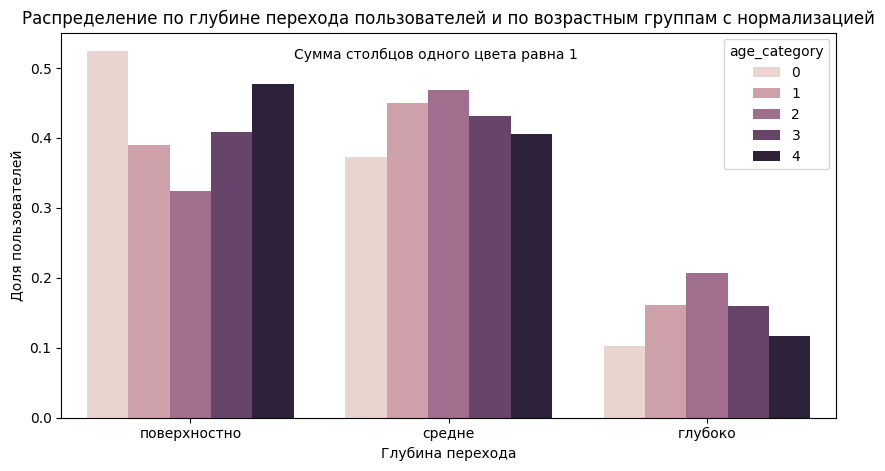

In [70]:
plt.figure(figsize=(10, 5)) 

sns.barplot(
    plot_df, 
    x='surf_depth', 
    y='proportion',
    hue='age_category',
    order=["поверхностно", "средне", "глубоко"],
)

plt.title('Распределение по глубине перехода пользователей и по возрастным группам с нормализацией')
plt.suptitle('Сумма столбцов одного цвета равна 1', y=0.85, fontsize=10)
plt.ylabel('Доля пользователей')
plt.xlabel('Глубина перехода')

plt.show()

С возрастом распределение глубины переходов меняется нелинейно: у младшей группы преобладают поверхностные переходы, у пользователей среднего возраста чаще встречаются средние и глубокие переходы, а у самой старшей группы снова возрастает доля поверхностных переходов. При этом во всех возрастных категориях основная часть пользователей остаётся на среднем уровне глубины перехода.

Данный признак потенциально полезен для обучения модели

#### 2.4.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.4.7 Вывод

Датасет `surf_depth` содержит информацию о глубине перехода пользователей по сайтам и может быть полезен для предсказания возрастной категории.

После очистки данных получено 5715 уникальных записей, дубликаты не обнаружены.

Пропусков не обнаружено, типы признаков корректны.

Распределение категорий `surf_depth` неравномерное: чаще встречаются `поверхностно` и `средне`, значительно реже — `глубоко`, что может быть полезно для модели во время разделения пользователей по возрастным категориям

In [71]:
# Сохранение обновленной таблицы surf_depth
dfs['surf_depth'] = df

### 2.5. Таблица `primary_device`

#### 2.5.1 Базовая информация о датасете

Датасет `primary_device` содержит информацию о типе основного устройства пользователя для выхода в интернет

**Столбцы:**
- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

In [72]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['primary_device']

In [73]:
# Размер датасета
df.shape

(5669, 3)

In [74]:
# Первые строки датасета
df.head()

,Unnamed: 0,user_id,primary_device
0,0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,1,9204-9558455be649d4e77945-b5e25d62,ПК
2,2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,4,abec-bb4092da51eb2233a928-e44ba074,ПК


#### 2.5.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [75]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [76]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB


In [77]:
# Приведение всех строковых столбцов к нижнему регистру
for col in df.columns:
    df[col] = df[col].str.lower()

df.head()

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,пк
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,пк


Подробнее рассмотрим значения признаков далее

#### 2.5.3 Анализ пропусков

In [78]:
# Пропуски по столбцам
df.isna().sum()

user_id           0
primary_device    0
dtype: int64

Пропусов не выявлено

В продакшен данных могут возникнуть пропуски. Для них в пайплайне предусмотрим заполнение самым часто встречаемым значением

#### 2.5.4 Выявление дубликатов

Проверим, встречается ли несколько раз пользователь с одинаковым id

In [79]:
# Количество дублей user_id
(df['user_id'].duplicated()).sum()

np.int64(0)

Дубликатов не выявлено

#### 2.5.5 Анализ категориальных признаков

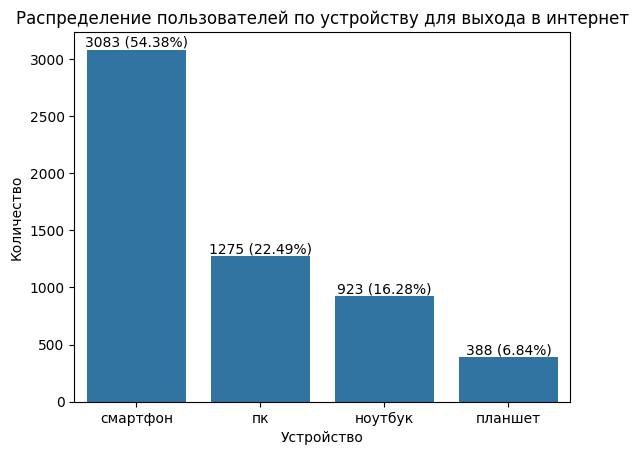

In [80]:
countplot(
    data=df,
    x='primary_device',
    title='Распределение пользователей по устройству для выхода в интернет',
    xlabel='Устройство',
    ylabel='Количество'
)

Пользователи заметно чаще посещают сайты со смартфонов, дале по частоте следуют ПК и ноутбуки и наименее популярны планшеты

Посмотрим на разделение по устройству в разрезе возрастной категории

In [81]:
# Объединение данных о глубине перехода с таргетом
df_with_target = pd.merge(dfs['users'], df, on='user_id', how='inner')
df_with_target.head(1)

,user_id,age_category,primary_device
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,смартфон


In [82]:
# Подготовка данных для построения графиков с нормализацией каждой возрастной группы
plot_df = (
    df_with_target
    .groupby(['primary_device', 'age_category'])
    .size()
    .reset_index(name='count')
)

plot_df['proportion'] = (
    plot_df['count'] /
    plot_df.groupby('age_category')['count'].transform('sum')
)

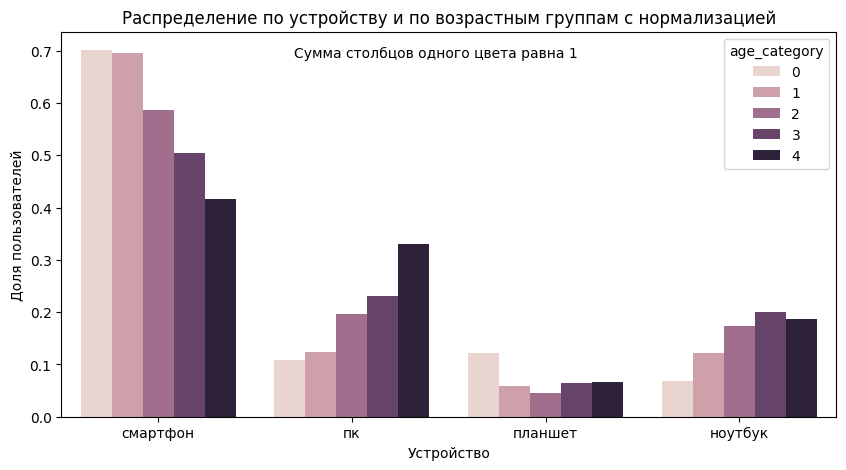

In [83]:
plt.figure(figsize=(10, 5)) 

sns.barplot(
    plot_df, 
    x='primary_device', 
    y='proportion',
    hue='age_category',
    order=['смартфон', 'пк', 'планшет', 'ноутбук'],
)

plt.title('Распределение по устройству и по возрастным группам с нормализацией')
plt.suptitle('Сумма столбцов одного цвета равна 1', y=0.85, fontsize=10)
plt.ylabel('Доля пользователей')
plt.xlabel('Устройство')

plt.show()

Распределение устройств по возрастным группам меняется преимущественно линейно: с увеличением возраста снижается доля пользователей смартфонов, тогда как использование ПК и ноутбуков постепенно растёт. Смартфон остаётся основным устройством во всех возрастных категориях, однако у старшей аудитории распределение между устройствами становится более сбалансированным. Использование планшетов во всех группах остаётся минимальным и не демонстрирует выраженного тренда.

#### 2.5.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.5.7 Вывод

Датасет `primary_device` содержит информацию об основном устройстве пользователя для выхода в интернет и может быть полезен для предсказания возрастной категории.

После очистки данных получено 5669 уникальных записей, дубликаты не обнаружены.

Пропусков не обнаружено, типы признаков корректны.

Распределение по устройствам неравномерное: чаще всего используется `смартфон`, реже — `пк` и `ноутбук`, минимально — `планшет`. С ростом возраста доля `смартфонов` снижается, а доля `пк` и `ноутбуков` увеличивается, что делает признак информативным для модели.

In [84]:
# Сохранение обновленной таблицы ads_activity
dfs['primary_device'] = df

### 2.6. Таблица `cloud_usage`

#### 2.6.1 Базовая информация о датасете

Датасет `cloud_usage` содержит информацию о том, обращался ли пользователь к облачным ресурсам

**Столбцы:**
- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — `True` означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты

In [85]:
# Для упрощения работы с датасетом, создадим ссылку
df = dfs['cloud_usage']

In [86]:
# Размер датасета
df.shape

(5680, 3)

In [87]:
# Первые строки датасета
df.head()

,Unnamed: 0,user_id,cloud_usage
0,0,a1e4-91c8a52eb855595e653f-298ce305,False
1,1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,4,b8cd-cbb2411db005115ca64d-32700c62,False


#### 2.6.2 Общий анализ признаков

Сразу удалим служебный столбец `Unnamed: 0`, который дублирует индекс

In [88]:
# Удаление служебного столбца
df = df.drop(columns=['Unnamed: 0'])

In [89]:
# Информация о столбцах
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


In [90]:
# Значения признака cloud_usage
df['cloud_usage'].value_counts()

cloud_usage
True     2951
False    2729
Name: count, dtype: int64

In [91]:
# Объединение данных с таргетом
df_with_target = pd.merge(dfs['users'], df, on='user_id', how='inner')
df_with_target.head(1)

,user_id,age_category,cloud_usage
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,False


In [92]:
# Подготовка данных для построения графиков с нормализацией каждой возрастной группы
plot_df = (
    df_with_target
    .groupby(['cloud_usage', 'age_category'])
    .size()
    .reset_index(name='count')
)

plot_df['proportion'] = (
    plot_df['count'] /
    plot_df.groupby('age_category')['count'].transform('sum')
)

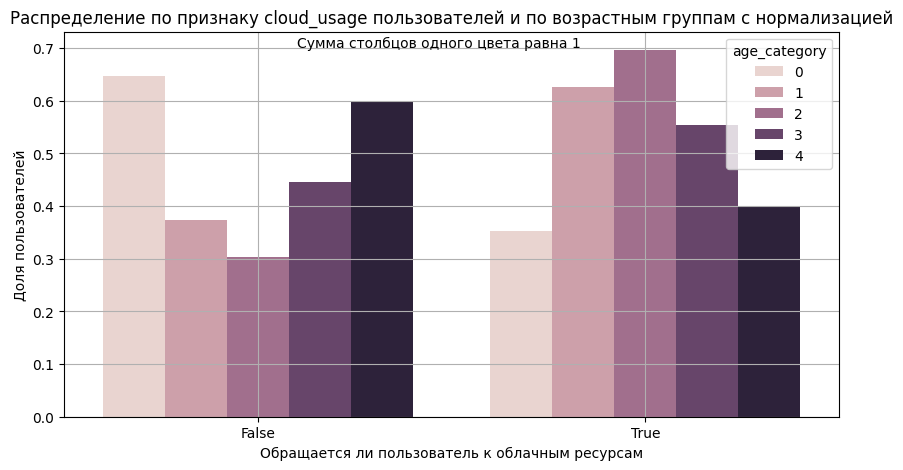

In [93]:
plt.figure(figsize=(10, 5)) 

sns.barplot(
    plot_df, 
    x='cloud_usage', 
    y='proportion',
    hue='age_category',
)

plt.title('Распределение по признаку cloud_usage пользователей и по возрастным группам с нормализацией')
plt.suptitle('Сумма столбцов одного цвета равна 1', y=0.87, fontsize=10)
plt.ylabel('Доля пользователей')
plt.xlabel('Обращается ли пользователь к облачным ресурсам')
plt.grid()

plt.show()

У признака прослеживатеся нелинейная зависимость с таргетом. Чем ближе пользователь ко второй категории 26-40 лет, тем больше вероятность, что он пользуется облачными ресурсами

Этот признак потенциально полезен для построения модели

#### 2.6.3 Анализ пропусков

In [94]:
# Пропуски по столбцам
df.isna().sum()

user_id        0
cloud_usage    0
dtype: int64

Пропусов не выявлено

В продакшен данных могут возникнуть пропуски. Для них в пайплайне предусмотрим заполнение самым часто встречаемым значением

#### 2.6.4 Выявление дубликатов

Проверим, встречается ли несколько раз пользователь с одинаковым id

In [95]:
# Количество дублей user_id
(df['user_id'].duplicated()).sum()

np.int64(0)

Дубликатов не выявлено

#### 2.6.5 Анализ категориальных признаков

Не требуется для данного датасета

#### 2.6.6 Анализ выбросов и распределений

Не требуется для данного датасета

#### 2.6.7 Вывод

Датасет `cloud_usage` содержит информацию об обращении пользователей к облачным ресурсам и может быть полезен для предсказания возрастной категории.

Данные состоят из 5680 уникальных записей, дубликаты не обнаружены.

Пропусков не обнаружено, типы признаков корректны.

Распределение признака `cloud_usage` относительно сбалансировано (`True` — 2951, `False` — 2729), при этом наблюдается зависимость от возрастной категории, поэтому признак стоит включить в обучение модели.

In [96]:
# Сохранение обновленной таблицы cloud_usage
dfs['cloud_usage'] = df

### 2.7 Выделение новых признаков (Feature Engineering)

В пункте 2.2.5 был выделен признак день недели пиковой активности. В дополнение к нему попробуем выделить еще несколько признаков

Основным источником новых признаков будет датасет `visits`. Остальные датасеты включают в себя уже сагрегированный признак, который можно использовать в текущем виде

Из датасета `visits` можно выделить следующие признаки:
- `daytime_activity_*` - доля активности пользователем в разное время суток
- `website_category_activity_*` - доля посещения пользователем категории сайтов 
- `weekday_activity_*` - доля активности в разнные дни недели. Этот признак дополняет и полностью заменяет признак из пункта 2.2.5

Они позволят получить более обшую картину пользователя, чем агрегация данных до одного признака

#### 2.7.1 Энтропия распределения активности

Отдельно рассмотрим то насколько разнообразно ведут себя пользоваетли разных возрастных категорий и может ли быть мера энтропия распределения активности нам полезна

Посчитаем энтропию двумя способами:
1. День недели и время посещения сайта. Всего 7*4=28 действий
2. День недели, время посещения сайта и категорий сайта. Всего 7\*4\*20=560 действий

Для начала посмотрим на этропию в первом варианте, если она покажет потенциальную эффективность на графиках, то попробуем и второй способ

Энтропию будем считать с нормализацией: <количество событий пользователя> / <максимально возможное число событий>

In [97]:
# Агрегация признаков для подсчета энтропии по первому признаку
df_entropy = dfs['visits'].copy()
df_entropy['dow'] = pd.to_datetime(df_entropy['date']).dt.day_name()
df_entropy['state'] = df_entropy['dow'] + '_' + df_entropy['daytime']

In [98]:
# Подсчет общего количества состояний
max_entropy_items = df_entropy['dow'].nunique() * df_entropy['daytime'].nunique()
max_entropy_items

28

In [99]:
df_entropy_by_user = (
    df_entropy.groupby("user_id")["state"]
      .nunique()
      .div(max_entropy_items)
      .reset_index(name="state_diversity")
)

df_entropy_by_user['state_diversity'].value_counts()

state_diversity
1.000000    1886
0.964286    1713
0.928571    1084
0.892857     717
0.857143     301
0.821429      98
0.785714      19
0.750000       7
0.714286       1
Name: count, dtype: int64

Энтропия по "день недели" + "время посещения сайта" получилось потенциально малоинформативной, так как очень большое число пользователей за неделю заходят в интернет каждый день и в каждый отрезок времени или почти в каждый. 

Но все таки посмотрим на разброс этропии в разрезе возрастных групп

In [100]:
# Объединение данных об энтропии с данными целевой переменной
df_entropy_by_user_with_target = pd.merge(dfs['users'], df_entropy_by_user, on='user_id', how='inner')
df_entropy_by_user_with_target.head(1)

,user_id,age_category,state_diversity
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4,1.0


In [101]:
# Вычисление средней энтропии для каждой возрастной группы
df_entropy_by_user_with_target.groupby('age_category')['state_diversity'].mean()

age_category
0    0.963490
1    0.955809
2    0.957907
3    0.948451
4    0.941696
Name: state_diversity, dtype: float64

Как и предполагалось энтропия по двум признакам в разрезе возрастных групп получилась почти одинаковой. Поэтому не содержит достаточно полезной информации для обучения модели

В таком случае и второй вариант не представляет интереса, так как добавление категорий в энтропию лишь даст "шум" + "посещенные категории сайтов". Но посмотрим еще на среднее количество категорий посещенных сайтов в неделю в разрезе возрастной группы

#### 2.7.2 Количество посещенных категорий

Рассчитаем среднее количество посещенных категорий за две недели и после посмотрим на эти данные в разрезе возрастной группы

In [102]:
# Подсчет количества посещенных категорий для каждого пользователя
df_visits = (
    dfs['visits']
    .groupby('user_id')['website_category']
    .nunique()
)

df_visits.value_counts()

website_category
19    3561
18    1619
17     509
16     116
15      19
14       2
Name: count, dtype: int64

In [103]:
df_visits_with_target = pd.merge(df_visits.reset_index(), dfs['users'], on='user_id', how='inner')

In [104]:
# Вычисление среднего количетсва посещенных категорий сайтов для каждой возрастной группы
df_visits_with_target.groupby('age_category')['website_category'].mean()

age_category
0    18.546307
1    18.595331
2    18.518416
3    18.468900
4    18.367497
Name: website_category, dtype: float64

Разнообразие посещаемых сайтов у большинства пользователей велико и составляет 17-19 за время наблюдений и пользователей каждой возрастной группы в среднем посещает 18-19 разлиных типов сайтов за две недели. Так что разнообразие категорий нет причины использовать при обучении модели

Но при этом содержать полезную информацию может частота посещения отдельных сайтов, описанный ранее признак `website_category_*`. Его эффективность проверим в процессе обучения моделей

#### 2.7.3 Вывод

По итогу выделим три группы дополнительных признаков из датасета `visits`:
- `daytime_activity_*` - доля активности пользователем в разное время суток
- `website_category_activity_*` - доля посещения пользователем категории сайтов 
- `weekday_activity_*` - доля активности в разнные дни недели

При этом важно из каждой группы удалить по 1 признаку, чтобы убрать линейную зависимость внутри группы признаков

### 2.8 Выводы по итогам EDA

По итогам EDA подтверждено, что данные пригодны для построения модели классификации возрастной категории: существенных проблем качества не обнаружено, пропуски отсутствуют, а дубликаты были точечно удалены в отдельных таблицах.

Наиболее полезными для модели выглядят поведенческие признаки из `visits` и агрегированные пользовательские характеристики из `ads_activity`, `surf_depth`, `primary_device` и `cloud_usage`. Для части признаков выявлен дисбаланс категорий, поэтому при обучении и оценке необходимо использовать стратификацию и метрики, устойчивые к дисбалансу классов.

Следующий этап — объединение таблиц в единый датасет по `user_id`, формирование финального набора признаков (включая новые агрегаты из `visits`) и переход к обучению моделей

## 3. Подготовка данных

### 3.1 Сборка единого датасета

Соберем итоговый датасет из разрозненных. Сразу оформим код в функцию, чтобы иметь возможность сохранить ее вместе с моделью. 

In [105]:
# Функция для создания групп признаков из категориального признака с подсчетом долей значений
def prepare_cat_proportions(df, col):
    return (
        df
        .groupby(['user_id', col])
        .size() # Подсчет количества отдельных значений признака
        .unstack()
        .rename_axis(None, axis=1)
        .T
        .apply(lambda x: x / x.sum()) # Вычисление доли каждого значения признака
        .fillna(0)
        .T
        .add_prefix(f'{col}_activity_') 
        .reset_index()
        .iloc[:,:-1] # Удаление одного из значений признака
    )

In [106]:
# Фунция для сбора датасета со всеми признаками
def prepare_features(
    df_visits,
    df_ads_activity,
    df_surf_depth,
    df_primary_device,
    df_cloud_usage,
    *,
    drop_user_id = True
):
    df_visits = df_visits.copy()
    df_visits['weekday'] = pd.to_datetime(df_visits['date']).dt.day_name()

    df = (
        df_ads_activity
        .merge(df_surf_depth, on='user_id')
        .merge(df_primary_device, on='user_id')
        .merge(df_cloud_usage, on='user_id')
        .merge(prepare_cat_proportions(df_visits, 'daytime'),  on='user_id')
        .merge(prepare_cat_proportions(df_visits, 'website_category'),  on='user_id')
        .merge(prepare_cat_proportions(df_visits, 'weekday'),  on='user_id')
        
    )

    if drop_user_id:
        df = df.drop(columns='user_id')

    return df

In [107]:
# Сборка датасета для дальйней работы
df = prepare_features(
    dfs['visits'],
    dfs['ads_activity'],
    dfs['surf_depth'],
    dfs['primary_device'],
    dfs['cloud_usage'],
    drop_user_id = False # user_id удалим на следующем шаге, после мерджа с таргетом
)

In [108]:
# Проверим, что признаки сформировались корректно
df.columns

Index(['user_id', 'ads_activity', 'surf_depth', 'primary_device',
       'cloud_usage', 'daytime_activity_вечер', 'daytime_activity_день',
       'daytime_activity_ночь', 'website_category_activity_category 01',
       'website_category_activity_category 02',
       'website_category_activity_category 03',
       'website_category_activity_category 04',
       'website_category_activity_category 05',
       'website_category_activity_category 06',
       'website_category_activity_category 07',
       'website_category_activity_category 08',
       'website_category_activity_category 09',
       'website_category_activity_category 10',
       'website_category_activity_category 11',
       'website_category_activity_category 12',
       'website_category_activity_category 13',
       'website_category_activity_category 14',
       'website_category_activity_category 15',
       'website_category_activity_category 16',
       'website_category_activity_category 17',
       'website_cate

Данные объединены корректно. Собраны как признаки изначательно поступившие в готовом для применения виде, так и сформированы новые на основе данных из таблицы `visits`

К полученным датасету добавим фрейм с таргетом для дальнейшего обучения. Это соединение происходит вне функции, так как в реальных данных таргет передаваться не будет, а функцию нужно сохранить для дальнейшего применения в продакшене

In [109]:
# Добавление в данные таргета и удаление `user_id`
df = df.merge(dfs['users'], on='user_id').drop(columns='user_id')

Можно обойтись и без этого слияния и сразу использовать данные как признаки (X) и таргет (y) в обучении. Но дополнительно нужно проверить данные на пропуски после всех обработок, что удобнее делать в виде одного общего датасета

In [110]:
# Проверка на пропуски
df.isna().sum().sum()

np.int64(0)

In [111]:
# Количество строк в датасете
len(df)

5205

В полученном датасете нет пропусков, значит на данном этапе мы и не будем их обрабатывать. Но как описывалось на этапе EDA, в пайплайн предобработки данных все равно будет заложена обработка пропусков для продакшена

### 3.2 Разделение на выборки

Теперь данные можно разделить на выборки. Воспользуемся следующим распределением:
- Обучающая выборка - 70%
- Валидационная выборка - 15%
- Тестовая выборка - 15%

Данное распределение выбрано с учетом относительно малого количества данных - 5205 строк

In [112]:
# Разделение датасета на признаки и таргет
X = df.drop(columns=TARGET_COL)
y = df[TARGET_COL]

X.shape, y.shape

((5205, 32), (5205,))

In [113]:
# Разделение данных
from sklearn.model_selection import train_test_split

# основной сплит
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

# делим тест на validation и test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_test,
    y_test,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_test,
)

In [114]:
# Размеры выборок
X_train.shape, X_valid.shape, X_test.shape, y_train.shape, y_valid.shape, y_test.shape

((4164, 32), (520, 32), (521, 32), (4164,), (520,), (521,))

Данные разделены корректно в требуемой пропорции и с сохранением баланса классов в таргетной переменной

## 4. Предобработка данных — построение пайплайна

Для удобства дальнейшей работы с признаками создадим функцию, которая возвращает пайплайн под нужные признаки

На текущем этапе пайплайн предобработки должен включить:
- Обработку пропусков всех признаков
- OHE кодирование для признаков `ads_activity`, `surf_depth` и `primary_device`

Сгенерированные ранее признаки уже закодированы в подходящем для применения в моделях формате

Масштабирование признаков не требуется. Признаки либо категориальные и закодированы с помощью OHE, либо сгенерированы ранее и их значения находятся в диапазоне 0-1

In [115]:
# Функция для формирования препроцессора с возможность указывать какие признаки требуется использовать
# Будет полезно для переиспользования препроцессора после отбора признаков
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer


def bool_to_int(X):
    return X.astype(int)

def get_preprocessor(selected_features=None):

    ohe_features = ['ads_activity', 'surf_depth', 'primary_device']
    bool_features = ['cloud_usage']

    return ColumnTransformer(
        transformers=[
            (
                'ohe',
                Pipeline([
                    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),
                    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
                ]),
                ohe_features
            ),
            (
                'bool',
                Pipeline([
                    ('to_int', FunctionTransformer(bool_to_int, feature_names_out='one-to-one')),
                    ('imputer', SimpleImputer(strategy='constant', fill_value=False))
                ]),
                bool_features
            )
        ], 
        remainder=SimpleImputer(strategy='median')
    )

Пайплайн готов к применению в моделях

## 4. Создание моделей

### 4.1 Создание базовой моделей

Базовая модель будет всегда предсказывать самую многочисленную группу пользователей. Для этого воспользуемся `DummyClassifier` со стратегией `most_frequent`

In [116]:
# Обучение DummyClassifier
from sklearn.dummy import DummyClassifier

model_dummy = DummyClassifier(strategy='most_frequent')
model_dummy.fit(X_train, y_train)
,

''

In [117]:
# Проверка dummy модели
pd.Series(model_dummy.predict(X_valid)).value_counts()

4    520
Name: count, dtype: int64

Модель всегда предсказывает класс `4`. Теперь оценим качество такой модели F1-мерой

**Тип усреднения метрки**
Так как для клиента одинаково важна точность по всем классам, то при вычислении метрик будем использовать **average='macro'**

In [118]:
# Оценка dummy модели
from sklearn.metrics import f1_score

f1_score_dummy = f1_score(y_valid, model_dummy.predict(X_valid), average='macro')
f1_score_dummy

0.09276218611521418

Базовая модель, которая всегда предсказывает класс `4` получила значение F1-меры 0.09. Это очень низкое значение, но оно станет базовым для будущих моделей

### 4.2 Создание модели логистической регресии

In [119]:
# Создание стандартного разбиения StratifiedKFold для проекта
from sklearn.model_selection import StratifiedKFold

cv_default = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [120]:
# Формирование модели
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced',
        max_iter=1000,
        # multi_class="multinomial" # Для старых версий sklearn
    ))
])

In [121]:
# Оценка модели
from sklearn.model_selection import cross_validate

cv_result_lr = cross_validate(
    model_lr,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=cv_default,
    n_jobs=-1
)

In [122]:
# Вывод оценки модели
f1_score_lr = pd.DataFrame(cv_result_lr).mean()['test_score']
f1_score_lr

np.float64(0.7114042059833086)

Простая модель линейной регресии показала результат F1-меры равный примерно 0.73, что уже в ~8 раз лучше чем базовая модель. Далее попробуем улучшить этот результат отбором признаков и подбором гиперпараметров

### 4.3 Создание модели модели опорных векторов

В процессе EDA мы выяснили, что много признаки имеют нелинейную зависимость с таргетом. Поэтому модель `SVC` с нелинейными ядрами потенциально может показать себя лучше, чем линейная модель

Для `SVC` мы не будем рассматривать линейное ядро, так как с линейной зависимостью хорошо справляется линейная регрессия и при этом обучается на порядок быстрее. Для `SVC` попробуем ядра:
- Полиномиальное (`poly`) - так как признаки часто меняются от 0 класса к 2, а потом к 4 начинают возвращаться, то полиномиальное ядро может показать хороший результат
- RFB (`rbf`) - сравнивает объеты по близости, с похожими точками. Часто дает наилучшие результаты

В конфигурации укажем `probability=False`, чтобы ускорить обучение моделей. Если финальной моделью станет `SVC`, то обучим модель с `probability=True`

In [123]:
# Формирование модели SVC с poly ядром
from sklearn.svm import SVC

model_svc_poly = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', SVC(
        kernel='poly',
        probability=False,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

In [124]:
# Оценка модели
cv_result_svc_poly = cross_validate(
    model_svc_poly,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=cv_default,
    n_jobs=-1
)

In [125]:
# Вывод оценки модели
f1_score_svc_poly = pd.DataFrame(cv_result_svc_poly).mean()['test_score']
f1_score_svc_poly

np.float64(0.6254727382942619)

In [126]:
# Формирование модели SVC с rbf ядром
from sklearn.svm import SVC

model_svc_rbf = Pipeline([
    ('preprocessor', get_preprocessor()),
    ('model', SVC(
        kernel='rbf',
        probability=False,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

In [127]:
# Оценка модели
cv_result_svc_rbf = cross_validate(
    model_svc_rbf,
    X_train,
    y_train,
    scoring='f1_macro',
    cv=cv_default,
    n_jobs=-1
)

In [128]:
# Вывод оценки модели
f1_score_svc_rbf = pd.DataFrame(cv_result_svc_rbf).mean()['test_score']
f1_score_svc_rbf

np.float64(0.4619837600237898)

### 4.4 Выводы

In [129]:
df_f1 = pd.DataFrame({
    'Dummy': {'f1': f1_score_dummy},
    'LogisticRegression': {'f1': f1_score_lr},
    'SVC (Poly)': {'f1': f1_score_svc_poly},
    'SVC (RBF)': {'f1': f1_score_svc_rbf},
}).T.sort_values(by='f1', ascending=False)

df_f1

,f1
LogisticRegression,0.711404
SVC (Poly),0.625473
SVC (RBF),0.461984
Dummy,0.092762


Все три созданные модели показали себя лучше чем базовая модель. Модель линейной регрессии показалас себя лучше чем модели SVC с нелинейными ядрами

Несмотря на то, что SVC показал себя хуже, продолжим работу с ним далее. Возможно отбор признаков и подбор гиперпараметров значительно изменят качество моделей

## 5. Отбор признаков

Для отбора признаков вспользуемся классом RFECV - wrapper-подход, при котором признаки отбираются на основе качества работы модели. Алгоритм итеративно обучает модель, удаляет наименее важные признаки и на каждом шаге оценивает результат с помощью кросс-валидации. Это позволяет автоматически определить оптимальное количество признаков и оставить только те, которые действительно улучшают качество модели по выбранной метрике.

Встроим RFECV в пайплайн каждой модели и посмотрим на оставшиеся признаки и F1-меры

### 5.1 Отбор признаков для логистической регресиии

In [130]:
# Функция для формирования RFECV
from sklearn.feature_selection import RFECV

def get_feature_selector(estimator):
    return RFECV(
        estimator=estimator,
        cv=cv_default,
        scoring="f1_macro",
        n_jobs=-1,
        min_features_to_select=5
    )

In [159]:
# Объект memory для кеширования пайплайнов, пригодится далее
from joblib import Memory

memory = Memory("./cache", verbose=0)

In [132]:
# Подготовка пайплайна с отбором признаков

model_lr = Pipeline([
    ("preprocess", get_preprocessor()),
    ("selection", get_feature_selector(
        estimator=LogisticRegression(
            random_state=RANDOM_STATE,
            class_weight='balanced',
            max_iter=1000,
            solver='saga',
            l1_ratio=1,
        )
    )),
    ("model", LogisticRegression(
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
], memory=memory)

In [160]:
# Запуск обучения модели с отбором признаков
model_lr.fit(X_train, y_train)
,

''

In [ ]:
# Вспомогательная функция для получения имен отобранных признаков
def get_selected_feautres(pipeline):
    selected_features = (
        pipeline
        .named_steps['preprocess']
        .get_feature_names_out()
    )[pipeline.named_steps['selection'].support_].tolist()

    return sorted(selected_features)

In [135]:
# Вызов препроцессора, чтобы узнать количество признаков, который попадают в модель
p = get_preprocessor()
p.fit(X_train)
total_features = len(p.get_feature_names_out())
total_features

38

In [136]:
# Получение признаков, которые были отобраны
selected_features_lr = get_selected_feautres(model_lr)
print(f"Общее число признаков: {total_features}")
print(f"Количество отобранных признаков: {len(selected_features_lr)}")

Общее число признаков: 38
Количество отобранных признаков: 28


In [137]:
print(f"F1-мера до отбора признаков: {f1_score_lr:.4f}")

f1_score_lr = f1_score(y_valid, model_lr.predict(X_valid), average='macro')

print(f"F1-мера после отбора признаков: {f1_score_lr:.4f}")

F1-мера до отбора признаков: 0.7114
F1-мера после отбора признаков: 0.7442


Обновленный пайплайн с отбором признаков дал небольшой прирост F1-меры на 0.03 и было удалено 10 признаков. 

### 5.2 Отбор признаков для метода опорных векторов

Повторим процесс из пункта 5.1, но теперь для воспользуемся моделями `SVC` с нелинейными ядрами

В данном случае есть проблема с применением вместе `RFECV` и `SVC(poly`)/`SVC(rbf)` - модели с нелинейным ядром не могут посчитать важность признака, которая используется внутри `RFECV` для их отбора. Поэтому в `RFECV` будет передана модель с линейным ядром, а конечные предсказания будет давать модель с нелинейным ядром

Применение `SequentialFeatureSelector` невозможно из-за большого количества признаков. Время поиска будет слишком большим

In [138]:
# Подготовка пайплайна с отбором признаков SVC(poly)
model_svc_poly = Pipeline([
    ("preprocess", get_preprocessor()),
    ("selection", get_feature_selector(
            estimator=SVC(
            kernel='linear',
            probability=False,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        )
    )),
    ("model", SVC(
        kernel='poly',
        probability=False,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
], memory=memory)

In [139]:
# Запуск обучения модели с отбором признаков
model_svc_poly.fit(X_train, y_train)
,

________________________________________________________________________________
[Memory] Calling sklearn.pipeline._fit_transform_one...
_fit_transform_one(RFECV(cv=StratifiedKFold(n_splits=5, random_state=1703, shuffle=True),
      estimator=SVC(class_weight='balanced', kernel='linear',
                    random_state=1703),
      min_features_to_select=5, n_jobs=-1, scoring='f1_macro'), 
array([[0.      , ..., 0.141304],
       ...,
       [0.      , ..., 0.182203]], shape=(4164, 38)), 
4889    0
4253    4
3060    4
1448    3
4813    2
       ..
570     1
3859    2
253     2
272     2
2145    3
Name: age_category, Length: 4164, dtype: int8, weight=None, message_clsname='Pipeline', message=None, params={ 'decision_function': {},
  'fit': {},
  'fit_predict': {},
  'fit_transform': {},
  'inverse_transform': {},
  'partial_fit': {},
  'predict': {},
  'predict_log_proba': {},
  'predict_proba': {},
  'score': {},
  'split': {},
  'transform': {}})
_____________________________________

''

In [140]:
# Получение признаков, которые были отобраны
selected_features_svc_poly = get_selected_feautres(model_svc_poly)
print(f"Общее число признаков: {total_features}")
print(f"Количество отобранных признаков: {len(selected_features_svc_poly)}")

Общее число признаков: 38
Количество отобранных признаков: 22


In [141]:
print(f"F1-мера до отбора признаков: {f1_score_svc_poly:.4f}")

f1_score_svc_poly = f1_score(y_valid, model_svc_poly.predict(X_valid), average='macro')

print(f"F1-мера после отбора признаков: {f1_score_svc_poly:.4f}")

F1-мера до отбора признаков: 0.6255
F1-мера после отбора признаков: 0.8285


In [142]:
# Подготовка пайплайна с отбором признаков SVC(rbf)
model_svc_rbf  = Pipeline([
    ("preprocess", get_preprocessor()),
    ("selection", get_feature_selector(
            estimator=SVC(
            kernel='linear',
            probability=False,
            random_state=RANDOM_STATE,
            class_weight='balanced'
        )
    )),
    ("model", SVC(
        kernel='rbf',
        probability=False,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
], memory=memory)

In [143]:
# Запуск обучения модели с отбором признаков
model_svc_rbf.fit(X_train, y_train)
,

''

In [144]:
# Получение признаков, которые были отобраны
selected_features_svc_rbf = get_selected_feautres(model_svc_rbf)
print(f"Общее число признаков: {total_features}")
print(f"Количество отобранных признаков: {len(selected_features_svc_rbf)}")

Общее число признаков: 38
Количество отобранных признаков: 22


In [145]:
print(f"F1-мера до отбора признаков: {f1_score_svc_rbf:.4f}")

f1_score_svc_rbf= f1_score(y_valid, model_svc_rbf.predict(X_valid), average='macro')

print(f"F1-мера после отбора признаков: {f1_score_svc_rbf:.4f}")

F1-мера до отбора признаков: 0.4620
F1-мера после отбора признаков: 0.8083


Обновленный пайплайны для `SVC` с отбором признаков дал значительный прирост F1-мер:
- на 0.2 для poly ядра
- на 0.34 для rbf ядра

В обоих случаях удалено 16 признаков

### 5.3 Выводы

In [146]:
# Обновленная таблица F1-меры 
# fs метка означает, что модель после отбора признаков (feature selection)
df_f1 = pd.concat([
    df_f1,
        pd.DataFrame({
        'LogisticRegression (fs)': {'f1': f1_score_lr},
        'SVC (Poly) (fs)': {'f1': f1_score_svc_poly},
        'SVC (RBF) (fs)': {'f1': f1_score_svc_rbf},
    }).T
]).sort_values(by='f1', ascending=False)
df_f1

,f1
SVC (Poly) (fs),0.828511
SVC (RBF) (fs),0.808272
LogisticRegression (fs),0.744240
LogisticRegression,0.711404
SVC (Poly),0.625473
SVC (RBF),0.461984
Dummy,0.092762


После отбора признаков отстающие по F1-мере модели SVC вышли в лидеры, опережая логистическую регрессию на 0.06–0.08 пункта. Это показывает, что для SVC качество признакового пространства критично: после удаления шумовых и слабых признаков модель лучше отделяет классы и дает более стабильный баланс precision/recall. 

В текущей постановке SVC выглядит как основной кандидат для финальной модели, а логистическую регрессию разумно оставить как интерпретируемый baseline.

## 6. Подбор гиперпараметров

Подбор гиперпараметров произведем для всех трех моделей. Будем использовать следующую сетку гиперпараметров

Для `LogisticRegression`:
- тип регуляризации (L1, L2, ElasticNet),
- сила регуляризацтт (C)


Для `SVC (poly)`:
- сила регуляризации (`C`): `0.01`, `0.1`, `1`, `10`, `100`
- параметр ядра (`gamma`): `'scale'`, `'auto'`, `0.001`, `0.01`, `0.1`, `1`
- степень полинома для `poly` (`degree`): `2`, `3`, `4`, `5`
- сдвиг в ядре (`coef0`): `0.0`, `0.1`, `0.5`, `1.0`, `2.0`


Для `SVC (rbf)`:
- сила регуляризации (`C`): `0.01`, `0.1`, `1`, `10`, `100`
- параметр ядра (`gamma`): `'scale'`, `'auto'`, `0.001`, `0.01`, `0.1`, `1`

В подборе будет участововать пайплайн с отбором признаков. Чтобы не переобучать подбор параметров каждый раз в pipeline, укажем параметр memory для кеширования

In [ ]:
from sklearn.model_selection import GridSearchCV

cv_grid_lr = GridSearchCV(
    estimator=model_lr,
    param_grid= {
        'model__solver': ['saga'],
        'model__l1_ratio': np.linspace(0, 1, 11),
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__max_iter': [1000]
    },
    scoring='f1_macro',
    cv=cv_default,
)

In [158]:
# Запуск Grid Search для Linear Regression
cv_grid_lr.fit(X_train, y_train)
,

________________________________________________________________________________
[Memory] Calling sklearn.pipeline._fit_transform_one...
_fit_transform_one(ColumnTransformer(remainder=SimpleImputer(strategy='median'),
                  transformers=[('ohe',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['ads_activity', 'surf_depth',
                                  'primary_device']),
                                ('bool',
                                 Pipeline(steps=[('to_int',
                                                  Functio

_______________________________________________fit_transform_one - 22.3s, 0.4min
________________________________________________________________________________
[Memory] Calling sklearn.pipeline._fit_transform_one...
_fit_transform_one(ColumnTransformer(remainder=SimpleImputer(strategy='median'),
                  transformers=[('ohe',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'))]),
                                 ['ads_activity', 'surf_depth',
                                  'primary_device']),
                                ('bool',
                                 Pip

/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie/linear-regression-experiments/venv/lib/python3.14/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/Users/a1/Desktop/learning/ml_for_newbie

''

In [ ]:
# Результаты
cv_grid_lr_results = pd.DataFrame(cv_grid_lr.cv_results_)

# cv_grid_lr_results[
#     ['mean_test_pr_auc', 'std_test_pr_auc', 'rank_test_pr_auc', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1', 'params']
# ].reset_index(drop=True).sort_values(by='mean_test_pr_auc', ascending=False).head(10)

cv_grid_lr_results

## 6. Обучение финальной модели

## 7. Подготовка артефактов модели для внедрения

## 8. Выводы о результатах работы